# Análisis exploratorio y entrenamiento del modelo — Clasificación de sentimientos (IMDB)

**Objetivo de este notebook:** profundizar el análisis exploratorio de datos (EDA) sobre el dataset de reseñas de IMDB, entender a nivel matemático/probabilístico qué hace `TfidfVectorizer`, visualizar el espacio vectorial resultante, y entrenar/comparar varios modelos de clasificación.

Este notebook retoma y **profundiza** el trabajo inicial hecho en `lenguaje_natural/1_analisis_sentimiento.ipynb`, agregando: verificación de calidad de datos, análisis estadístico de longitud de reseñas, explicación matemática completa de TF-IDF, visualización 2D/3D del espacio vectorial, y entrenamiento comparativo de 3 modelos.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización (2D y 3D)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
%matplotlib inline

## 1. Carga de datos

Un `DataFrame` es una tabla en memoria: cada fila es una reseña, cada columna una variable (`review` = texto, `sentiment` = etiqueta positiva/negativa).

In [2]:
df = pd.read_csv('data/IMDB Dataset.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 50000 filas x 2 columnas


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Calidad de datos: nulos y duplicados

Antes de cualquier análisis estadístico hay que verificar la calidad de los datos crudos.

- **Ventaja de revisar esto primero:** evita conclusiones erróneas. Un duplicado infla artificialmente la frecuencia de ciertos patrones textuales, sesgando el vocabulario y los pesos IDF que calcularemos más adelante.
- **Desventaja de eliminar duplicados sin pensarlo:** si dos reseñas idénticas son legítimas (p. ej. el mismo comentario publicado en dos fuentes distintas que se combinaron al construir el dataset), eliminarlas reduce el tamaño muestral sin una razón real. Aquí asumimos que son ruido de recolección, una decisión razonable pero no la única válida.

In [3]:
print("Valores nulos por columna:")
print(df.isnull().sum())

n_duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_duplicados} ({df.duplicated().mean()*100:.2f}% del total)")

Valores nulos por columna:
review       0
sentiment    0
dtype: int64

Filas duplicadas: 418 (0.84% del total)


In [4]:
filas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
filas_despues = df.shape[0]
print(f"Filas eliminadas por duplicado: {filas_antes - filas_despues}")
print(f"Nuevo total de filas: {filas_despues}")

Filas eliminadas por duplicado: 418
Nuevo total de filas: 49582


## 3. Balance de clases

En un problema de clasificación **binaria**, si una clase domina (p. ej. 90% positivas), un modelo que siempre prediga "positive" tendría 90% de exactitud **sin haber aprendido nada**. Esto se conoce como la **paradoja de la exactitud** (*accuracy paradox*).

Formalmente, la exactitud base (baseline) de un clasificador trivial es:
$$ \text{exactitud base} = \frac{\text{tamaño de la clase mayoritaria}}{\text{total de observaciones}} $$

Cualquier modelo que entrenemos debe superar claramente este baseline para considerarse útil.

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Exactitud base (predecir siempre la clase mayoritaria): 50.19%


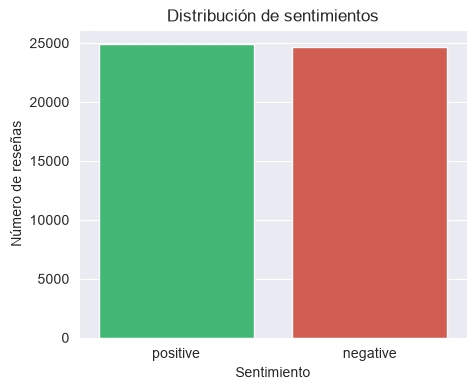

In [5]:
conteo = df['sentiment'].value_counts()
print(conteo)
print(f"\nExactitud base (predecir siempre la clase mayoritaria): {conteo.max()/conteo.sum()*100:.2f}%")

plt.figure(figsize=(5,4))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index,
            palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribución de sentimientos')
plt.ylabel('Número de reseñas')
plt.xlabel('Sentimiento')
plt.show()

## 4. Longitud de las reseñas

Analizamos la longitud (en palabras) de cada reseña con estadística descriptiva: media, mediana, desviación estándar y **asimetría (skewness)**.

- **Asimetría > 0:** distribución con cola hacia la derecha (hay reseñas muy largas que son atípicas frente a la mayoría, que es más corta).
- Esto importa porque reseñas extremadamente largas generan vectores TF-IDF con muchos más términos distintos de cero, lo cual puede afectar el entrenamiento si no se controla (p. ej. con normalización, que aplicaremos más adelante).

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: n_palabras, dtype: float64

Asimetría (skewness): 2.17


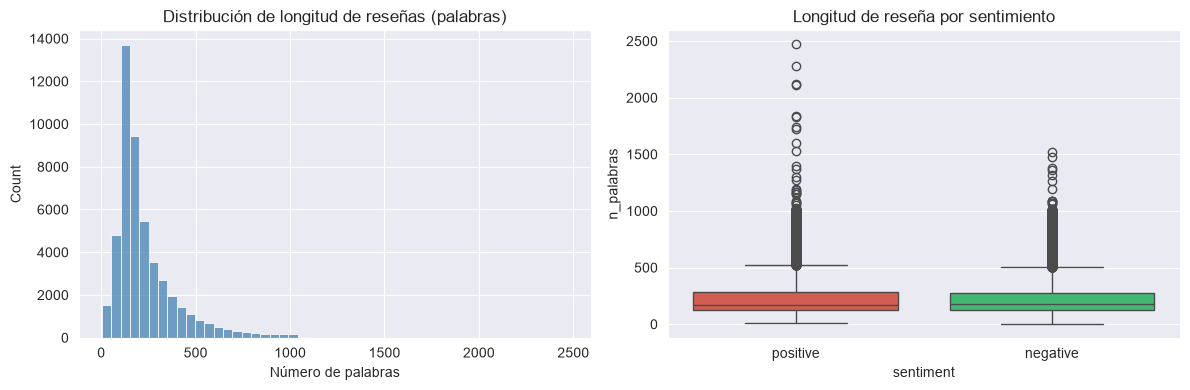

In [6]:
df['n_palabras'] = df['review'].str.split().apply(len)

print(df['n_palabras'].describe())
print(f"\nAsimetría (skewness): {df['n_palabras'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['n_palabras'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de longitud de reseñas (palabras)')
axes[0].set_xlabel('Número de palabras')

sns.boxplot(data=df, x='sentiment', y='n_palabras', hue='sentiment',
            ax=axes[1], palette=['#e74c3c', '#2ecc71'], legend=False)
axes[1].set_title('Longitud de reseña por sentimiento')

plt.tight_layout()
plt.show()

## 5. Muestreo balanceado

Replicamos el paso del notebook de referencia: tomar un subconjunto de 5 000 reseñas positivas + 5 000 negativas en lugar del dataset completo.

**Punto importante a aclarar:** el dataset original **ya está balanceado 50/50** (lo confirmamos en la sección 3). Por lo tanto, este submuestreo **no corrige un sesgo** — su única función aquí es **reducir el volumen de datos** para que el entrenamiento y la exploración sean más rápidos.

- **Ventaja:** entrenamiento e inspección de matrices mucho más ágiles durante la fase exploratoria.
- **Desventaja (matemáticamente relevante):** menos datos = mayor varianza en las estimaciones del modelo y mayor riesgo de que el modelo final generalice peor. Para un modelo de producción convendría usar el dataset completo.
- **Mejora sobre el notebook de referencia:** allí se tomaban las primeras 5 000 filas de cada clase con slicing (`[:5000]`), lo cual puede introducir sesgo si el CSV tiene algún orden implícito (p. ej. reseñas agrupadas por película). Aquí usamos `sample(random_state=42)` para tomar una muestra aleatoria reproducible.

In [7]:
N = 5000
df_pos = df[df['sentiment'] == 'positive'].sample(n=N, random_state=42)
df_neg = df[df['sentiment'] == 'negative'].sample(n=N, random_state=42)
df_reviews = pd.concat([df_pos, df_neg]).reset_index(drop=True)

print(df_reviews['sentiment'].value_counts())

sentiment
positive    5000
negative    5000
Name: count, dtype: int64


## 6. División train/test

Se separan los datos en entrenamiento y prueba para poder **estimar el error de generalización**: qué tan bien funcionará el modelo con reseñas que nunca ha visto.

- **`test_size=0.33`:** hay un *trade-off* sesgo-varianza en la **estimación del error**. Más datos de prueba → estimación del error más confiable (menor varianza), pero menos datos de entrenamiento → el modelo aprende de menos ejemplos (potencialmente peor). 33% es una convención común, no una ley matemática.
- **`random_state=42`:** fija la semilla del generador pseudoaleatorio → los mismos resultados en cada ejecución (reproducibilidad).
- **`stratify=...`:** mejora sobre el notebook de referencia — garantiza que la proporción de clases en train y test sea **idéntica** a la del conjunto original, evitando que el azar del split desbalancee alguno de los dos subconjuntos.

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df_reviews,
    test_size=0.33,
    random_state=42,
    stratify=df_reviews['sentiment']
)

train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

print(f"Entrenamiento: {train_x.shape[0]} reseñas")
print(f"Prueba: {test_x.shape[0]} reseñas")
print("\nProporción de clases en entrenamiento:")
print(train_y.value_counts(normalize=True))
print("\nProporción de clases en prueba:")
print(test_y.value_counts(normalize=True))

Entrenamiento: 6700 reseñas
Prueba: 3300 reseñas

Proporción de clases en entrenamiento:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Proporción de clases en prueba:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


## 7. TF-IDF en profundidad

Un modelo matemático no entiende palabras, entiende números. La forma más simple de convertir texto en números es **Bag of Words (BoW)**: contar cuántas veces aparece cada palabra del vocabulario en cada documento. El problema: palabras muy frecuentes en *todos* los documentos ("the", "movie") dominan el conteo sin aportar información discriminativa.

**TF-IDF (Term Frequency – Inverse Document Frequency)** corrige esto ponderando cada palabra por qué tan "informativa" es.

**Term Frequency (TF):** frecuencia del término $t$ en el documento $d$:
$$ tf(t,d) = \text{número de veces que } t \text{ aparece en } d $$

**Inverse Document Frequency (IDF):** penaliza palabras que aparecen en muchos documentos (poco discriminativas). Scikit-learn usa la versión suavizada:
$$ idf(t) = \ln\left(\frac{1+n}{1+df(t)}\right) + 1 $$
donde $n$ es el número total de documentos y $df(t)$ el número de documentos que contienen $t$.

- El **logaritmo** comprime la escala: pasar de aparecer en 10 a 100 documentos no debe pesar 10 veces menos, sino de forma decreciente (rendimientos marginales decrecientes).
- El **"+1" (suavizado)** en numerador y denominador evita división por cero y evita que $idf = 0$ para palabras presentes en todos los documentos.

**TF-IDF:**
$$ tfidf(t,d) = tf(t,d) \times idf(t) $$

Finalmente, cada vector-fila (documento) se **normaliza a norma L2 = 1**:
$$ \hat{v} = \frac{v}{\|v\|_2} $$
Esto pone a documentos de distinta longitud en la misma escala, y hace que el **producto punto entre dos vectores normalizados sea exactamente su similitud coseno** — la métrica estándar para comparar textos.

**Interpretación en álgebra lineal:** cada reseña se convierte en un vector en $\mathbb{R}^n$ (n = tamaño del vocabulario, típicamente decenas de miles). La colección completa de reseñas es una matriz $X \in \mathbb{R}^{m \times n}$ (m documentos, n términos). Como cada reseña usa solo una fracción mínima del vocabulario total, casi todas las entradas de $X$ son cero → **matriz dispersa (sparse)**. Guardarla como matriz densa desperdiciaría muchísima memoria; scikit-learn usa `scipy.sparse.csr_matrix`, que solo almacena las posiciones y valores distintos de cero.

⚠️ **Punto metodológico crítico — fuga de datos (*data leakage*):** el vectorizador se **ajusta (`fit`) únicamente con el conjunto de entrenamiento**. Si se ajustara con todo el dataset (incluyendo test) antes de dividir, el vocabulario y los valores de IDF "verían" información del conjunto de prueba, inflando artificialmente el desempeño reportado sin reflejar el desempeño real ante datos nuevos.

**Sobre `stop_words='english'`:** elimina palabras muy comunes sin carga semántica propia (the, a, is...).

- **Ventaja:** reduce dimensionalidad y ruido.
- **Desventaja real para este problema:** es una lista genérica en inglés que puede eliminar palabras relevantes en un contexto de sentimiento. Por ejemplo, la lista de sklearn incluye **"not"**, una negación crítica ("not good" pierde el "not" y el vector resultante se parece al de "good"). Lo verificamos abajo. Una alternativa más cuidadosa sería construir una lista de stopwords personalizada que conserve las negaciones.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

print("'not' está en la lista de stopwords de sklearn:", 'not' in ENGLISH_STOP_WORDS)

tfidf = TfidfVectorizer(stop_words='english')

# fit_transform: aprende vocabulario + IDF usando SOLO train, y transforma train
train_x_vector = tfidf.fit_transform(train_x)

# transform: reutiliza el vocabulario/IDF ya aprendidos para transformar test (nunca fit sobre test)
test_x_vector = tfidf.transform(test_x)

print(f"Tamaño del vocabulario: {len(tfidf.get_feature_names_out())}")
print(f"Forma matriz train: {train_x_vector.shape}")
print(f"Forma matriz test: {test_x_vector.shape}")

'not' está en la lista de stopwords de sklearn: True


Tamaño del vocabulario: 43695
Forma matriz train: (6700, 43695)
Forma matriz test: (3300, 43695)


### Esparsidad de la matriz

Calculamos qué porcentaje de la matriz TF-IDF de entrenamiento son ceros, para justificar numéricamente por qué se almacena como matriz dispersa.

In [10]:
n_elementos = train_x_vector.shape[0] * train_x_vector.shape[1]
n_no_cero = train_x_vector.nnz
esparsidad = 1 - (n_no_cero / n_elementos)

print(f"Elementos totales: {n_elementos:,}")
print(f"Elementos distintos de cero: {n_no_cero:,}")
print(f"Esparsidad: {esparsidad*100:.4f}% de la matriz son ceros")

Elementos totales: 292,756,500
Elementos distintos de cero: 595,778
Esparsidad: 99.7965% de la matriz son ceros


### Inspección de una reseña como vector

Igual que en el notebook de referencia, observamos qué términos quedaron con peso TF-IDF distinto de cero en la primera reseña de entrenamiento, ordenados de mayor a menor peso.

In [11]:
primera_resenia = pd.DataFrame.sparse.from_spmatrix(
    train_x_vector,
    index=train_x.index,
    columns=tfidf.get_feature_names_out()
).iloc[0]

print("Texto original (primeros 300 caracteres):\n", train_x.iloc[0][:300], "...\n")
print("Términos con TF-IDF distinto de cero (mayor a menor peso):")
print(primera_resenia[primera_resenia != 0].sort_values(ascending=False).head(15))

Texto original (primeros 300 caracteres):
 The Swedish filmmaker Roy Andersson's latest film You, the Living is not easy to review. One of the reasons is that in his own words he has broken with the Anglo-Saxon tradition of story-telling, in all essence the template of most Western film productions. Another reason might be that although Roy  ...

Términos con TF-IDF distinto de cero (mayor a menor peso):
andersson     0.219432
different     0.187214
film          0.169594
dreams         0.14491
shootings     0.140286
dream         0.130268
reality       0.115403
living        0.112497
despite       0.108911
roy           0.108753
reach           0.1067
characters    0.090909
language      0.089155
speak         0.086973
outside       0.085854
Name: 3211, dtype: Sparse[float64, nan]


## 8. Visualización del espacio vectorial (2D y 3D)

El vocabulario tiene miles de dimensiones — imposible de graficar directamente. Usamos **`TruncatedSVD`** (Descomposición en Valores Singulares truncada) para reducir a 2 y 3 dimensiones.

**¿Por qué SVD y no PCA?** PCA requiere centrar los datos (restar la media), lo cual **destruye la dispersión** de la matriz (convierte los ceros en valores densos) y sería inviable en memoria. SVD trabaja directamente sobre la matriz dispersa: descompone $X \approx U \Sigma V^T$ y nos quedamos con los primeros $k$ componentes (los que capturan la mayor varianza posible en $k$ dimensiones). Esta es, de hecho, la base matemática de **LSA (Latent Semantic Analysis)**.

Al reducir de ~20 000+ dimensiones a solo 2 o 3, se pierde la gran mayoría de la varianza — no esperamos una separación perfecta, pero el gráfico ayuda a **intuir** si existe alguna estructura que separe reseñas positivas de negativas.

In [12]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=3, random_state=42)
train_x_svd = svd.fit_transform(train_x_vector)

print(f"Varianza explicada por cada componente: {svd.explained_variance_ratio_}")
print(f"Varianza explicada acumulada (3 componentes): {svd.explained_variance_ratio_.sum()*100:.2f}%")

Varianza explicada por cada componente: [0.00629343 0.00704889 0.00423743]
Varianza explicada acumulada (3 componentes): 1.76%


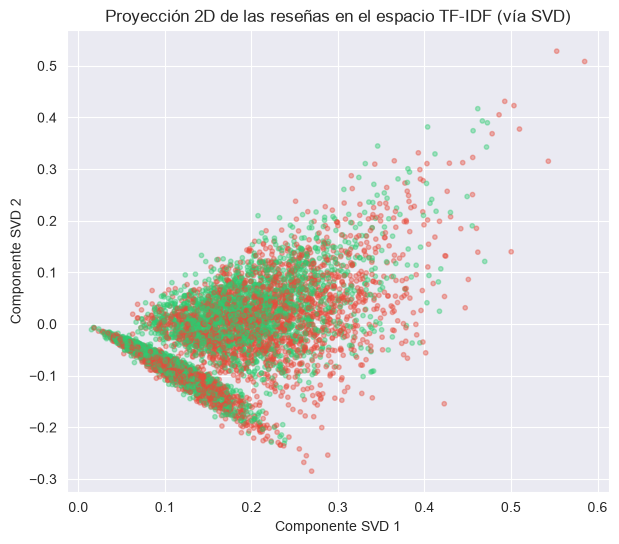

In [13]:
colores = train_y.map({'positive': '#2ecc71', 'negative': '#e74c3c'})

plt.figure(figsize=(7, 6))
plt.scatter(train_x_svd[:, 0], train_x_svd[:, 1], c=colores, alpha=0.4, s=10)
plt.xlabel('Componente SVD 1')
plt.ylabel('Componente SVD 2')
plt.title('Proyección 2D de las reseñas en el espacio TF-IDF (vía SVD)')
plt.show()

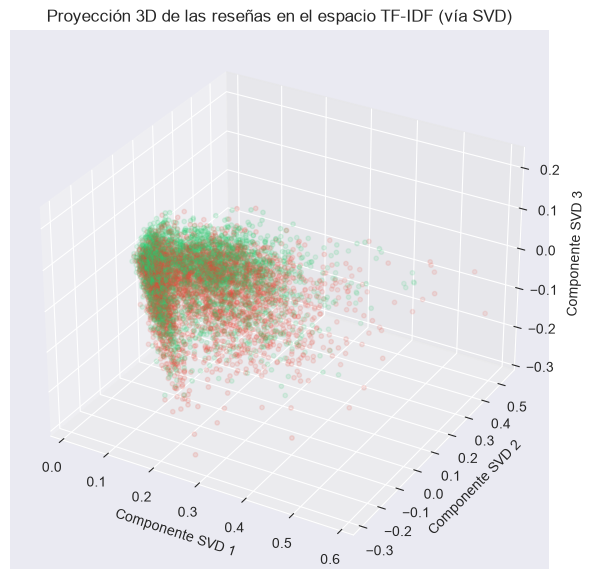

In [14]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='3d')
ax.scatter(train_x_svd[:, 0], train_x_svd[:, 1], train_x_svd[:, 2], c=colores, alpha=0.4, s=10)
ax.set_xlabel('Componente SVD 1')
ax.set_ylabel('Componente SVD 2')
ax.set_zlabel('Componente SVD 3')
ax.set_title('Proyección 3D de las reseñas en el espacio TF-IDF (vía SVD)')
plt.show()

**Interpretación:** con solo 2-3 de miles de dimensiones (menos del 1% de la varianza total, según el resultado impreso arriba) es normal ver mucho traslape entre clases — se descartó casi toda la información. Si aun así se aprecia alguna tendencia de agrupamiento por color, es una señal alentadora de que **un modelo lineal en el espacio completo** (que sí usa todas las dimensiones) tiene buenas posibilidades de separar las clases.

## 9. Entrenamiento del modelo

Entrenamos y comparamos 3 modelos clásicos, apropiados para datos de alta dimensión y dispersos como TF-IDF:

**1. Naive Bayes Multinomial** — modelo probabilístico basado en el Teorema de Bayes:
$$ P(y \mid x) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)^{x_i} $$
Asume (ingenuamente) que las palabras son condicionalmente independientes entre sí dado el sentimiento. Es una suposición falsa en la práctica (las palabras sí se correlacionan), pero funciona sorprendentemente bien en texto gracias a la alta dimensionalidad. Es además el más rápido de entrenar.

**2. Regresión Logística** — modelo lineal que estima la probabilidad de la clase positiva con la función sigmoide sobre una combinación lineal de las features:
$$ P(y=1 \mid x) = \sigma(w^Tx + b) = \frac{1}{1+e^{-(w^Tx+b)}} $$
Los pesos $w$ se ajustan maximizando la verosimilitud de los datos observados (equivalente a minimizar la entropía cruzada). Cada peso indica cuánto "empuja" cada palabra hacia positivo o negativo — es el más interpretable de los tres.

**3. SVM lineal (`LinearSVC`)** — busca el hiperplano que **maximiza el margen** entre clases:
$$ \min_{w,b} \ \frac{1}{2}\|w\|^2 + C\sum_i \max(0,\ 1-y_i(w^Tx_i+b)) $$
El parámetro $C$ penaliza los puntos que caen del lado incorrecto o muy cerca del límite. Suele rendir muy bien en espacios de alta dimensión como TF-IDF.

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelos = {
    'Naive Bayes (Multinomial)': MultinomialNB(),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'SVM Lineal': LinearSVC(random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(train_x_vector, train_y)
    pred = modelo.predict(test_x_vector)
    acc = accuracy_score(test_y, pred)
    resultados[nombre] = acc
    print(f"\n{'='*55}\n{nombre} — Exactitud: {acc*100:.2f}%\n{'='*55}")
    print(classification_report(test_y, pred))


Naive Bayes (Multinomial) — Exactitud: 84.55%
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85      1650
    positive       0.87      0.81      0.84      1650

    accuracy                           0.85      3300
   macro avg       0.85      0.85      0.85      3300
weighted avg       0.85      0.85      0.85      3300


Regresión Logística — Exactitud: 85.55%
              precision    recall  f1-score   support

    negative       0.88      0.83      0.85      1650
    positive       0.84      0.88      0.86      1650

    accuracy                           0.86      3300
   macro avg       0.86      0.86      0.86      3300
weighted avg       0.86      0.86      0.86      3300


SVM Lineal — Exactitud: 85.76%
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      1650
    positive       0.85      0.88      0.86      1650

    accuracy                           0.86      3300
   macro

### Comparación de modelos

Recordar el baseline calculado en la sección 3 (~50%, dataset balanceado): cualquier resultado por debajo de eso indicaría un modelo peor que adivinar al azar.

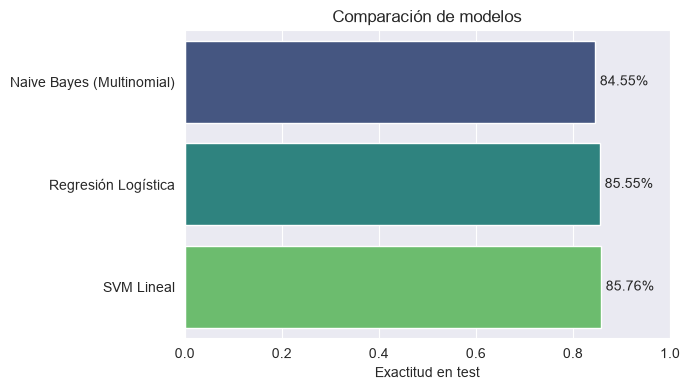

In [16]:
plt.figure(figsize=(7, 4))
nombres = list(resultados.keys())
valores = list(resultados.values())
sns.barplot(x=valores, y=nombres, hue=nombres, palette='viridis', legend=False)
plt.xlabel('Exactitud en test')
plt.xlim(0, 1)
for i, v in enumerate(valores):
    plt.text(v + 0.01, i, f"{v*100:.2f}%", va='center')
plt.title('Comparación de modelos')
plt.tight_layout()
plt.show()

### Matriz de confusión del mejor modelo

La matriz de confusión muestra, para cada clase real, cuántas veces el modelo acertó y cuántas veces confundió positivo con negativo (o viceversa) — información que el número único de "exactitud" no revela (p. ej. si el modelo falla sistemáticamente más en una clase que en otra).

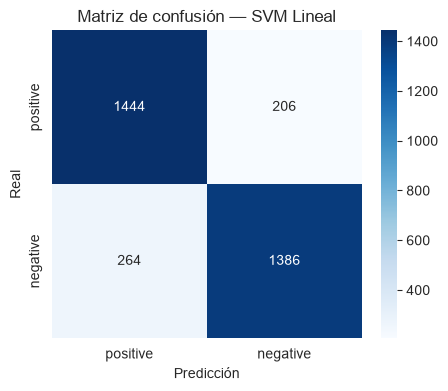

Mejor modelo: SVM Lineal (85.76% de exactitud)


In [17]:
mejor_nombre = max(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_nombre]
pred_mejor = mejor_modelo.predict(test_x_vector)

cm = confusion_matrix(test_y, pred_mejor, labels=['positive', 'negative'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión — {mejor_nombre}')
plt.show()

print(f"Mejor modelo: {mejor_nombre} ({resultados[mejor_nombre]*100:.2f}% de exactitud)")

## 10. Conclusiones y siguientes pasos

**Qué se hizo en este notebook:**
- Verificación de calidad de datos (nulos, duplicados) antes de cualquier análisis.
- Confirmación del balance de clases y cálculo del baseline de exactitud.
- Análisis estadístico de la longitud de las reseñas (media, mediana, asimetría).
- Submuestreo balanceado reproducible (mejorado respecto al notebook de referencia).
- División train/test estratificada, evitando fuga de datos en el vectorizador.
- Explicación matemática completa de TF-IDF (TF, IDF suavizado, normalización L2, matriz dispersa).
- Visualización 2D y 3D del espacio vectorial mediante SVD truncada.
- Entrenamiento y comparación de 3 modelos: Naive Bayes, Regresión Logística y SVM lineal.

**Siguientes pasos sugeridos (pendientes de tu aprobación):**
1. Notebook específico con varios ejemplos de reseñas para leer e interpretar matrices dispersas (mencionado en las reglas del proyecto).
2. Ajuste de hiperparámetros con validación cruzada (`GridSearchCV`) para el modelo ganador.
3. Mejoras de preprocesamiento: n-gramas, lematización, manejo explícito de negaciones.
4. Persistir el modelo y el vectorizador entrenados (con `joblib`) para reutilizarlos sin reentrenar — **el vectorizador de producción debe ser exactamente el mismo** (mismo vocabulario e IDF) que el usado en entrenamiento.
5. Llevar el modelo a producción (API con Flask) y construir la interfaz UI/UX que explique al usuario el recorrido reseña → tokens → vector TF-IDF → predicción.